In [ ]:
!pip install pandas openpyxl

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/01 Retail Inventory.xlsx')
print("DataFrame columns:", df.columns.tolist())
df.head()


DataFrame columns: ['Product ID', 'Product Name', 'Category', 'Supplier Name', 'Unit Cost', 'Retail Price', 'Opening Stock', 'Units Sold', 'Closing Stock', 'Reorder Point', 'Stock Status']


,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
0,PRD-1001,Wine Glasses,Home & Kitchen,Heritage Brands,23.78,38.89,135,118,17,30,Low Stock
1,PRD-1002,Eye Mask,Beauty,Coastal Trading,15.67,24.53,86,10,76,9,In Stock
2,PRD-1003,Resistance Band,Sports & Outdoors,National Supply Group,5.59,11.88,319,195,124,47,In Stock
3,PRD-1004,Action Figure,Toys & Games,Pacific Wholesale,9.72,18.01,173,140,33,39,Low Stock
4,PRD-1005,Serving Tray,Home & Kitchen,Coastal Trading,8.22,13.90,32,8,24,7,In Stock


In [45]:
#task 1
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product ID     1000 non-null   object 
 1   Product Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Supplier Name  1000 non-null   object 
 4   Unit Cost      1000 non-null   float64
 5   Retail Price   1000 non-null   float64
 6   Opening Stock  1000 non-null   int64  
 7   Units Sold     1000 non-null   int64  
 8   Closing Stock  1000 non-null   int64  
 9   Reorder Point  1000 non-null   int64  
 10  Stock Status   1000 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 86.1+ KB


In [47]:
#task1
#check data types
df.dtypes

,0
Product ID,object
Product Name,object
Category,object
Supplier Name,object
Unit Cost,float64
Retail Price,float64
Opening Stock,int64
Units Sold,int64
Closing Stock,int64
Reorder Point,int64


In [48]:
#task1 check missing values
df.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Supplier Name,0
Unit Cost,0
Retail Price,0
Opening Stock,0
Units Sold,0
Closing Stock,0
Reorder Point,0


In [50]:
#task 2 data cleaning
#check duplicates records
df.duplicated().sum()

np.int64(0)

In [51]:
#task2 remove duplicates
df = df.drop_duplicates()

In [52]:
#task2 handle missing values
df.dropna(inplace=True)

In [55]:
#task2 validate stock fields
df[df["Closing Stock"] < 0]

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status


In [56]:
#task 3 Exploratory Data Analysis
#Category-wise product count
category_count = df.groupby("Category")["Product Name"].count()
print(category_count)

Category
Beauty               134
Clothing             116
Electronics          126
Grocery              119
Home & Kitchen       124
Office Supplies      126
Sports & Outdoors    132
Toys & Games         123
Name: Product Name, dtype: int64


In [57]:
#task3 Category-wise units sold
category_sales = df.groupby("Category")["Units Sold"].sum()
print(category_sales)

Category
Beauty               18137
Clothing             13736
Electronics          17621
Grocery              15364
Home & Kitchen       18387
Office Supplies      17112
Sports & Outdoors    16979
Toys & Games         19704
Name: Units Sold, dtype: int64


In [58]:
#task 3 top 10 best selling product
top_products = df.sort_values(by="Units Sold", ascending=False).head(10)
print(top_products)

    Product ID     Product Name           Category         Supplier Name  \
721   PRD-1722     Water Bottle  Sports & Outdoors  Summit Wholesale Inc   
476   PRD-1477      Canned Soup            Grocery  Global Source Direct   
791   PRD-1792   Coffee Mug Set     Home & Kitchen       Coastal Trading   
673   PRD-1674    LED Desk Lamp        Electronics    Metro Distributors   
810   PRD-1811     Coloring Set       Toys & Games     Pacific Wholesale   
243   PRD-1244      Notebook A5    Office Supplies    AllGoods Supply Co   
970   PRD-1971     Baseball Cap           Clothing    AllGoods Supply Co   
550   PRD-1551          Whistle  Sports & Outdoors   Premier Merchandise   
931   PRD-1932    Rice Crackers            Grocery    AllGoods Supply Co   
469   PRD-1470  Building Blocks       Toys & Games       Heritage Brands   

     Unit Cost  Retail Price  Opening Stock  Units Sold  Closing Stock  \
721       1.38          2.68            489         463             26   
476       8.12 

In [60]:
#task 3 top low stock product
low_stock = df.sort_values(by="Closing Stock").head(10)
print(low_stock)

    Product ID       Product Name           Category          Supplier Name  \
45    PRD-1046      Basic T-Shirt           Clothing         United Imports   
385   PRD-1386       Coloring Set       Toys & Games    Premier Merchandise   
819   PRD-1820        Notebook A5    Office Supplies        Coastal Trading   
654   PRD-1655  Storage Container     Home & Kitchen  National Supply Group   
425   PRD-1426      Nail File Set             Beauty     AllGoods Supply Co   
391   PRD-1392           Eye Mask             Beauty      Pacific Wholesale   
703   PRD-1704     Coffee Mug Set     Home & Kitchen     AllGoods Supply Co   
977   PRD-1978        Cotton Pads             Beauty  National Supply Group   
698   PRD-1699            Whistle  Sports & Outdoors   Global Source Direct   
709   PRD-1710        Dry Shampoo             Beauty   Summit Wholesale Inc   

     Unit Cost  Retail Price  Opening Stock  Units Sold  Closing Stock  \
45       24.64         41.77             42          38 

In [62]:
#Supplier-wise inventory distribution.
supplier_products = df.groupby("Supplier Name")["Product Name"].count()
print(supplier_products)

Supplier Name
AllGoods Supply Co        72
Coastal Trading          103
Global Source Direct     103
Heritage Brands          109
Metro Distributors        89
National Supply Group    116
Pacific Wholesale         98
Premier Merchandise      119
Summit Wholesale Inc      92
United Imports            99
Name: Product Name, dtype: int64


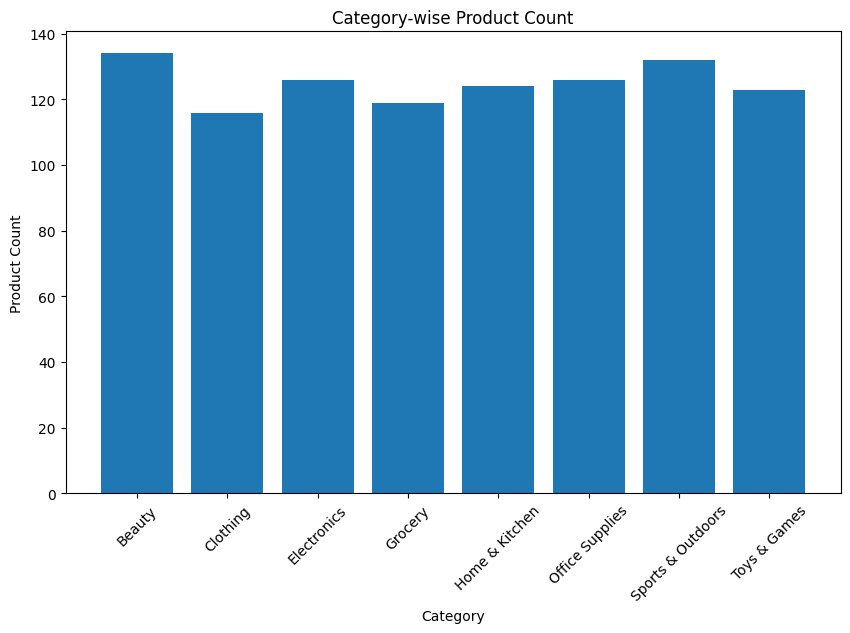

In [63]:
#task 4
#data visualization
# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(category_count.index, category_count.values)
plt.xlabel("Category")
plt.ylabel("Product Count")
plt.title("Category-wise Product Count")
plt.xticks(rotation=45)
plt.show()

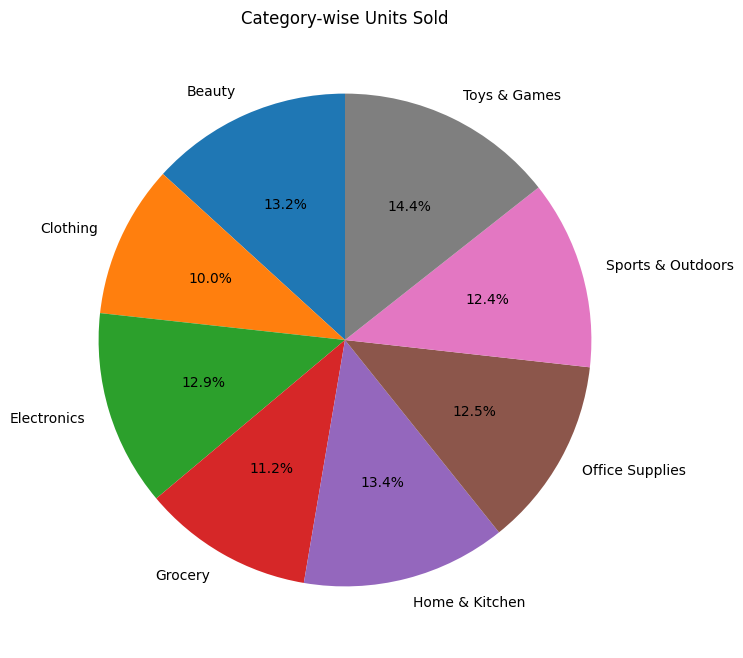

In [64]:
#task 4 pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=90)
plt.title("Category-wise Units Sold")
plt.show()


Text(0.5, 1.0, 'Distribution of Units Sold')

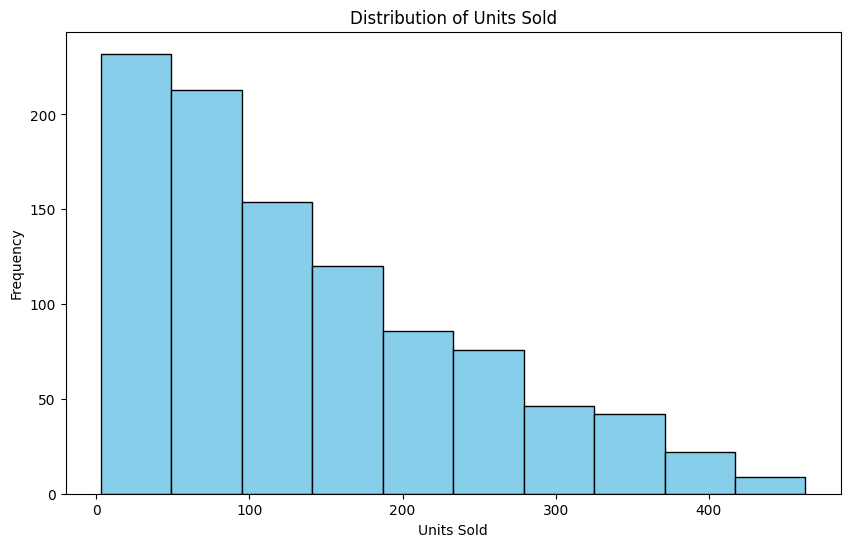

In [66]:
#task 4
#histogram
plt.figure(figsize=(10, 6))
plt.hist(df["Units Sold"], bins=10, color='skyblue', edgecolor='black')
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.title("Distribution of Units Sold")

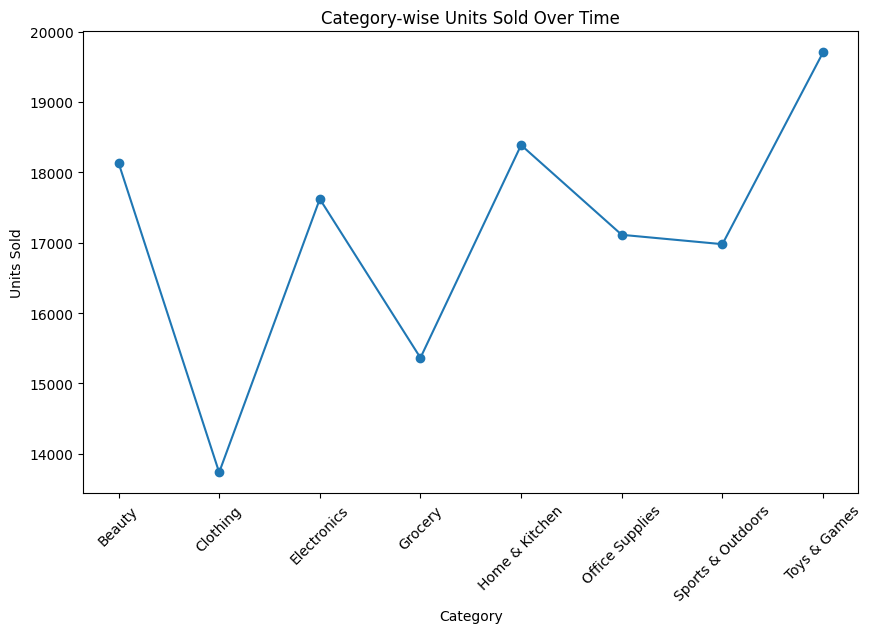

In [67]:
#task 4
#line graph
plt.figure(figsize=(10, 6))
plt.plot(category_sales.index, category_sales.values, marker='o', linestyle='-')
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.title("Category-wise Units Sold Over Time")
plt.xticks(rotation=45)
plt.show()

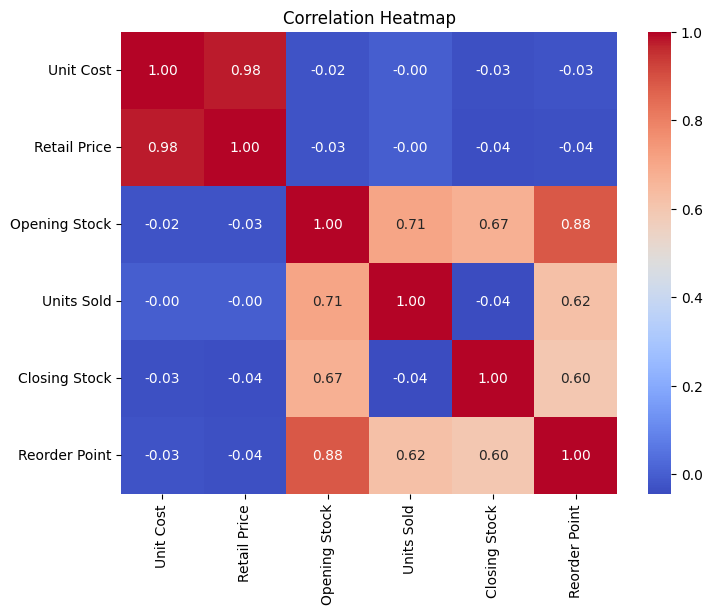

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#task 4
# correction heatmap
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()